In [ ]:
#1
import os
import glob
import numpy as np
import torch
from PIL import Image, ImageDraw
import xml.etree.ElementTree as ET
import torchvision.transforms.functional as TF
import random

os.environ['RAPIDS_NO_INITIALIZE'] = '1'
os.environ['CUPY_CACHE_SAVE_CUDA_SOURCE'] = '0'

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]

PROMPTS_CLASSES = {
    "voilier"         : "aerial view sailboat with mast on water",
    "yacht"           : "aerial view luxury motor yacht on water",
    "jet_ski"         : "aerial view jet ski personal watercraft on water",
    "bateau_peche"    : "aerial view fishing boat trawler commercial harbor on water",
    "navire_croisiere": "aerial view large white cruise ship passenger vessel port",
    "navire_militaire": "aerial view grey military warship frigate navy vessel",
    "remorqueur"      : "aerial view tugboat short wide red orange hull port",
    "cargo"           : "aerial view cargo ship bulk carrier flat deck freight port",
}

IMAGE_SIZE = 1008


def parse_cvat_xml(xml_path):
    batch_dir = os.path.dirname(os.path.abspath(xml_path))
    tree      = ET.parse(xml_path)
    root      = tree.getroot()
    samples   = []

    for image_elem in root.findall('.//image'):
        img_name = image_elem.get('name')
        img_w    = int(image_elem.get('width'))
        img_h    = int(image_elem.get('height'))
        img_path = os.path.join(batch_dir, img_name)

        if not os.path.exists(img_path):
            print(f"  ⚠ Non trouvée : {img_name}")
            continue

        masks_meta = []
        for poly in image_elem.findall('polygon'):
            label      = poly.get('label')
            points_str = poly.get('points')
            coords     = [
                tuple(map(float, p.split(',')))
                for p in points_str.split(';')
            ]
            if len(coords) < 3:
                continue
            xs_c = [c[0] for c in coords]
            ys_c = [c[1] for c in coords]
            masks_meta.append({
                'label'  : label,
                'coords' : coords,
                'bbox'   : (min(xs_c), min(ys_c),
                            max(xs_c), max(ys_c)),
                'center' : (sum(xs_c)/len(xs_c),
                            sum(ys_c)/len(ys_c)),
            })

        if masks_meta:
            samples.append({
                'image_path' : img_path,
                'width'      : img_w,
                'height'     : img_h,
                'masks'      : masks_meta,
            })
    return samples


def charger_split(split_dir):
    samples = []
    xmls    = sorted(glob.glob(
        f'{split_dir}/**/*_cvat.xml', recursive=True
    ))
    print(f"\nChargement {split_dir} ({len(xmls)} XML trouvés)")
    for xml in xmls:
        batch_samples = parse_cvat_xml(xml)
        samples      += batch_samples
        print(f"  ✓ {os.path.basename(xml):<35} "
              f"→ {len(batch_samples):>3} images  "
              f"| {sum(len(s['masks']) for s in batch_samples):>5} masques")
    total = sum(len(s['masks']) for s in samples)
    print(f"  TOTAL : {len(samples)} images  |  {total} masques")
    return samples


# ── Charger les samples uniquement ───────────────────────────────────
# Les DataLoaders seront créés dans le code training
# après détection de DECODER_SIZE
DATASET_DIR   = '/home/jupyter-p2m/dataset'
train_samples = charger_split(f'{DATASET_DIR}/train')
val_samples   = charger_split(f'{DATASET_DIR}/val')
test_samples  = charger_split(f'{DATASET_DIR}/test')

print(f"\n{'='*50}")
print(f"Samples prêts ✓")
print(f"  Train : {sum(len(s['masks']) for s in train_samples):>6} masques")
print(f"  Val   : {sum(len(s['masks']) for s in val_samples):>6} masques")
print(f"  Test  : {sum(len(s['masks']) for s in test_samples):>6} masques")
print(f"  IMAGE_SIZE = {IMAGE_SIZE}")
print(f"  DECODER_SIZE sera détecté dans le code training")
print(f"{'='*50}")

In [2]:
#2
import os
import glob
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import torchvision.transforms.functional as TF
import xml.etree.ElementTree as ET
from ultralytics import SAM
from tqdm import tqdm
from collections import defaultdict

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
CHECKPOINT = '/home/jupyter-p2m/checkpoints'
os.makedirs(CHECKPOINT, exist_ok=True)

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]

print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Charger SAM 3 ─────────────────────────────────────────────────────
model = SAM('/home/jupyter-p2m/sam3.pt')
sam   = model.model.to(DEVICE)

for name, param in sam.named_parameters():
    if 'image_encoder' in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

total     = sum(p.numel() for p in sam.parameters())
trainable = sum(p.numel() for p in sam.parameters()
                if p.requires_grad)
print(f"Paramètres entraînables : {trainable:,} / {total:,} "
      f"({100*trainable/total:.1f}%)")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 1 — Détecter DECODER_SIZE depuis le modèle directement
# sans avoir besoin d'un DataLoader existant
# ─────────────────────────────────────────────────────────────────────
print("\nDétection taille sortie décodeur SAM 3...")
sam.eval()
with torch.no_grad():
    # Créer une image factice à la bonne taille
    dummy_img  = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    dummy_bbox = torch.tensor(
        [[100., 100., 500., 500.]]
    ).to(DEVICE)

    backbone_out   = sam.forward_image(dummy_img)
    image_embed    = backbone_out['vision_features']
    high_res_feats = None
    if sam.use_high_res_features_in_sam:
        high_res_feats = [
            backbone_out['backbone_fpn'][0],
            backbone_out['backbone_fpn'][1],
        ]
    boxes_reshaped = dummy_bbox.unsqueeze(1)
    sparse_emb, dense_emb = sam.sam_prompt_encoder(
        points=None, boxes=boxes_reshaped, masks=None,
    )
    image_pe = sam.sam_prompt_encoder.get_dense_pe()
    test_out, _, _, _ = sam.sam_mask_decoder(
        image_embeddings         = image_embed,
        image_pe                 = image_pe,
        sparse_prompt_embeddings = sparse_emb,
        dense_prompt_embeddings  = dense_emb,
        multimask_output         = False,
        high_res_features        = high_res_feats,
        repeat_image             = False,
    )
    DECODER_SIZE = test_out.shape[-1]
    print(f"  ✓ DECODER_SIZE = {DECODER_SIZE}×{DECODER_SIZE}")
sam.train()


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 2 — Dataset et DataLoaders avec la bonne taille
# ─────────────────────────────────────────────────────────────────────
class SAM3DatasetV2(Dataset):
    def __init__(self, samples, image_size=1008,
                 decoder_size=288, augment=False):
        self.image_size   = image_size
        self.decoder_size = decoder_size
        self.augment      = augment
        self.items        = []
        for sample in samples:
            for mask_info in sample['masks']:
                self.items.append({
                    'image_path' : sample['image_path'],
                    'orig_w'     : sample['width'],
                    'orig_h'     : sample['height'],
                    'coords'     : mask_info['coords'],
                    'label'      : mask_info['label'],
                    'center'     : mask_info['center'],
                    'bbox'       : mask_info['bbox'],
                })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item   = self.items[idx]
        orig_w = item['orig_w']
        orig_h = item['orig_h']

        image = Image.open(item['image_path']).convert('RGB')

        mask_img = Image.new('L', (orig_w, orig_h), 0)
        ImageDraw.Draw(mask_img).polygon(item['coords'], fill=1)
        mask_np  = np.array(mask_img, dtype=np.uint8)
        if mask_np.sum() == 0:
            mask_np[orig_h//2, orig_w//2] = 1

        image    = image.resize(
            (self.image_size, self.image_size), Image.BILINEAR
        )
        mask_pil = Image.fromarray(mask_np * 255).resize(
            (self.image_size, self.image_size), Image.NEAREST
        )

        if self.augment:
            if random.random() > 0.5:
                image    = TF.hflip(image)
                mask_pil = TF.hflip(mask_pil)
            if random.random() > 0.5:
                image    = TF.vflip(image)
                mask_pil = TF.vflip(mask_pil)
            angle    = random.choice([0, 90, 180, 270])
            image    = TF.rotate(image,    angle)
            mask_pil = TF.rotate(mask_pil, angle)

        image_t = TF.to_tensor(image)
        image_t = TF.normalize(
            image_t,
            mean=[0.485, 0.456, 0.406],
            std= [0.229, 0.224, 0.225]
        )

        mask_t = torch.from_numpy(
            np.array(mask_pil, dtype=np.float32) / 255.0
        ).unsqueeze(0)

        # Masque GT à la taille native du décodeur
        mask_decoder = torch.nn.functional.interpolate(
            mask_t.unsqueeze(0),
            size=(self.decoder_size, self.decoder_size),
            mode='nearest'
        ).squeeze(0)

        scale_x = self.image_size / orig_w
        scale_y = self.image_size / orig_h
        x_min, y_min, x_max, y_max = item['bbox']
        bbox_scaled = torch.tensor([
            x_min * scale_x, y_min * scale_y,
            x_max * scale_x, y_max * scale_y,
        ], dtype=torch.float32)

        cx, cy = item['center']
        point_scaled = torch.tensor([
            cx * scale_x, cy * scale_y,
        ], dtype=torch.float32)

        return {
            'image'      : image_t,
            'mask'       : mask_t,
            'mask_256'   : mask_decoder,
            'bbox'       : bbox_scaled,
            'point'      : point_scaled,
            'label'      : item['label'],
            'image_path' : item['image_path'],
        }


# Créer les datasets et DataLoaders
print(f"\nCréation datasets avec decoder_size={DECODER_SIZE}...")
train_ds_v2 = SAM3DatasetV2(
    train_samples,
    image_size=IMAGE_SIZE, decoder_size=DECODER_SIZE, augment=True
)
val_ds_v2 = SAM3DatasetV2(
    val_samples,
    image_size=IMAGE_SIZE, decoder_size=DECODER_SIZE, augment=False
)

train_loader_v2 = DataLoader(
    train_ds_v2, batch_size=8, shuffle=True,
    num_workers=4, pin_memory=True, prefetch_factor=2,
)
val_loader_v2 = DataLoader(
    val_ds_v2, batch_size=8, shuffle=False,
    num_workers=4, pin_memory=True,
)

print(f"  Train : {len(train_ds_v2)} items → {len(train_loader_v2)} batchs")
print(f"  Val   : {len(val_ds_v2)}   items → {len(val_loader_v2)} batchs")

# Vérification
b = next(iter(train_loader_v2))
print(f"\nVérification batch :")
print(f"  image    : {b['image'].shape}")
print(f"  mask_256 : {b['mask_256'].shape}")
print(f"  bbox     : {b['bbox'].shape}")


# ─────────────────────────────────────────────────────────────────────
# LOSS ET FORWARD
# ─────────────────────────────────────────────────────────────────────
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_w = bce_weight
        self.bce   = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target, smooth=1e-6):
        pred  = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return 1 - ((2*inter+smooth)/(union+smooth)).mean()

    def forward(self, pred, target):
        return (self.bce_w * self.bce(pred, target)
              + (1-self.bce_w) * self.dice_loss(pred, target))

criterion = BCEDiceLoss(bce_weight=0.5)


def sam3_forward(sam, images, bboxes):
    backbone_out   = sam.forward_image(images)
    image_embed    = backbone_out['vision_features']
    high_res_feats = None
    if sam.use_high_res_features_in_sam:
        high_res_feats = [
            backbone_out['backbone_fpn'][0],
            backbone_out['backbone_fpn'][1],
        ]
    boxes_reshaped = bboxes.unsqueeze(1)
    sparse_embeddings, dense_embeddings = sam.sam_prompt_encoder(
        points=None, boxes=boxes_reshaped, masks=None,
    )
    image_pe = sam.sam_prompt_encoder.get_dense_pe()
    low_res_masks, _, _, _ = sam.sam_mask_decoder(
        image_embeddings         = image_embed,
        image_pe                 = image_pe,
        sparse_prompt_embeddings = sparse_embeddings,
        dense_prompt_embeddings  = dense_embeddings,
        multimask_output         = False,
        high_res_features        = high_res_feats,
        repeat_image             = False,
    )
    return low_res_masks


def calculer_iou_batch(pred_masks, true_masks, threshold=0.5):
    pred_bin = (torch.sigmoid(pred_masks) > threshold).float()
    inter    = (pred_bin * true_masks).sum(dim=(1, 2, 3))
    union    = (pred_bin + true_masks).clamp(0,1).sum(dim=(1,2,3))
    return (inter / (union + 1e-6)).mean().item()


# ─────────────────────────────────────────────────────────────────────
# OPTIMISEUR + REPRISE AUTOMATIQUE
# ─────────────────────────────────────────────────────────────────────
EPOCHS    = 50
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, sam.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)


def trouver_dernier_checkpoint(checkpoint_dir):
    patterns = [
        f'{checkpoint_dir}/checkpoint_arret_epoch*.pt',
        f'{checkpoint_dir}/checkpoint_early_stop_epoch*.pt',
        f'{checkpoint_dir}/checkpoint_epoch*.pt',
    ]
    tous = []
    for pattern in patterns:
        tous += glob.glob(pattern)
    if not tous:
        return None

    def extraire_epoch(path):
        match = re.search(r'epoch(\d+)', os.path.basename(path))
        return int(match.group(1)) if match else 0

    tous.sort(key=extraire_epoch)
    return tous[-1]


dernier_ckpt = trouver_dernier_checkpoint(CHECKPOINT)

if dernier_ckpt:
    print(f"\n✓ Reprise depuis : {os.path.basename(dernier_ckpt)}")
    ckpt = torch.load(dernier_ckpt, map_location=DEVICE)
    sam.load_state_dict(ckpt['model_state'])
    start_epoch = ckpt['epoch'] + 1
    best_iou    = ckpt['best_iou']

    if start_epoch > EPOCHS:
        print(f"  ⚠ Epochs dépassé → 20 epochs supplémentaires")
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, sam.parameters()),
            lr=5e-5, weight_decay=1e-4
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=20, eta_min=1e-7
        )
        EPOCHS = start_epoch + 19
        print(f"  → Reprise epoch {start_epoch} → {EPOCHS}")
        print(f"  → lr = 5e-5")
    else:
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])

    print(f"  epoch de reprise : {start_epoch}")
    print(f"  best IoU connu   : {best_iou:.4f}")
    print(f"  lr actuel        : "
          f"{optimizer.param_groups[0]['lr']:.6f}")
else:
    print("\nAucun checkpoint → démarrage depuis epoch 1")
    start_epoch = 1
    best_iou    = 0.0


# ── train_one_epoch ───────────────────────────────────────────────────
def train_one_epoch(sam, loader, optimizer, criterion, epoch):
    sam.train()
    total_loss = 0.0
    total_iou  = 0.0
    class_iou  = defaultdict(list)
    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [TRAIN]')
    for batch in pbar:
        images   = batch['image'].to(DEVICE)
        masks_gt = batch['mask_256'].to(DEVICE)
        bboxes   = batch['bbox'].to(DEVICE)
        labels   = batch['label']
        optimizer.zero_grad()
        pred_masks = sam3_forward(sam, images, bboxes)
        loss = criterion(pred_masks, masks_gt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            sam.parameters(), max_norm=1.0
        )
        optimizer.step()
        batch_iou   = calculer_iou_batch(pred_masks, masks_gt)
        total_loss += loss.item()
        total_iou  += batch_iou
        pred_bin = (torch.sigmoid(pred_masks) > 0.5).float()
        for i, label in enumerate(labels):
            inter = (pred_bin[i] * masks_gt[i]).sum()
            union = (pred_bin[i] + masks_gt[i]).clamp(0,1).sum()
            class_iou[label].append((inter/(union+1e-6)).item())
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'iou' : f'{batch_iou:.4f}',
            'lr'  : f'{optimizer.param_groups[0]["lr"]:.6f}'
        })
    n = len(loader)
    print(f"\n  IoU par classe (train) :")
    for cls in CLASS_NAMES:
        ious = class_iou.get(cls, [0])
        print(f"    {cls:<22} {sum(ious)/len(ious):.4f}")
    return total_loss/n, total_iou/n


def validate(sam, loader, criterion, epoch):
    sam.eval()
    total_loss = 0.0
    total_iou  = 0.0
    class_iou  = defaultdict(list)
    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [VAL]  ')
    with torch.no_grad():
        for batch in pbar:
            images   = batch['image'].to(DEVICE)
            masks_gt = batch['mask_256'].to(DEVICE)
            bboxes   = batch['bbox'].to(DEVICE)
            labels   = batch['label']
            pred_masks = sam3_forward(sam, images, bboxes)
            loss      = criterion(pred_masks, masks_gt)
            batch_iou = calculer_iou_batch(pred_masks, masks_gt)
            total_loss += loss.item()
            total_iou  += batch_iou
            pred_bin = (torch.sigmoid(pred_masks) > 0.5).float()
            for i, label in enumerate(labels):
                inter = (pred_bin[i] * masks_gt[i]).sum()
                union = (pred_bin[i] + masks_gt[i]).clamp(0,1).sum()
                class_iou[label].append((inter/(union+1e-6)).item())
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'iou' : f'{batch_iou:.4f}'
            })
    n = len(loader)
    print(f"\n  IoU par classe (val) :")
    for cls in CLASS_NAMES:
        ious = class_iou.get(cls, [0])
        print(f"    {cls:<22} {sum(ious)/len(ious):.4f}")
    return total_loss/n, total_iou/n


# ─────────────────────────────────────────────────────────────────────
# BOUCLE PRINCIPALE
# ─────────────────────────────────────────────────────────────────────
SAVE_EVERY       = 2
epochs_no_improv = 0
patience         = 10
history          = []

print(f"\n{'='*60}")
print(f"  Fine-tuning SAM 3")
print(f"  Depuis epoch   : {start_epoch}")
print(f"  Jusqu'à epoch  : {EPOCHS}")
print(f"  Best IoU connu : {best_iou:.4f}")
print(f"  Mask GT size   : {DECODER_SIZE}×{DECODER_SIZE}")
print(f"  Sauvegarde     : toutes les {SAVE_EVERY} epochs")
print(f"{'='*60}\n")

for epoch in range(start_epoch, EPOCHS + 1):

    if os.path.exists('/home/jupyter-p2m/STOP_TRAINING'):
        os.remove('/home/jupyter-p2m/STOP_TRAINING')
        print(f"\n  Arrêt propre à l'epoch {epoch}")
        torch.save({
            'epoch'          : epoch,
            'model_state'    : sam.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_iou'       : best_iou,
        }, f'{CHECKPOINT}/checkpoint_arret_epoch{epoch:02d}.pt')
        break

    train_loss, train_iou = train_one_epoch(
        sam, train_loader_v2, optimizer, criterion, epoch
    )
    val_loss, val_iou = validate(
        sam, val_loader_v2, criterion, epoch
    )
    scheduler.step()

    print(f"\nEpoch {epoch:02d}/{EPOCHS}")
    print(f"  Train → loss: {train_loss:.4f}  IoU: {train_iou:.4f}")
    print(f"  Val   → loss: {val_loss:.4f}  IoU: {val_iou:.4f}")
    print(f"  LR    → {optimizer.param_groups[0]['lr']:.6f}")

    if val_iou > best_iou:
        best_iou         = val_iou
        epochs_no_improv = 0
        torch.save(
            sam.state_dict(),
            f'{CHECKPOINT}/sam3_maritime_best.pt'
        )
        print(f"  ✓ Meilleur modèle sauvegardé (IoU={best_iou:.4f})")
    else:
        epochs_no_improv += 1
        print(f"  Pas d'amélioration depuis "
              f"{epochs_no_improv} epochs")

    if epochs_no_improv >= patience:
        print(f"\n  Early stopping à l'epoch {epoch}")
        print(f"  Meilleur val IoU : {best_iou:.4f}")
        torch.save({
            'epoch'          : epoch,
            'model_state'    : sam.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_iou'       : best_iou,
        }, f'{CHECKPOINT}/checkpoint_early_stop_epoch{epoch:02d}.pt')
        break

    if epoch % SAVE_EVERY == 0:
        ckpt_path = f'{CHECKPOINT}/checkpoint_epoch{epoch:02d}.pt'
        torch.save({
            'epoch'          : epoch,
            'model_state'    : sam.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_iou'       : best_iou,
        }, ckpt_path)
        print(f"  ✓ Checkpoint sauvegardé (epoch {epoch})")

        ckpts = sorted(
            glob.glob(f'{CHECKPOINT}/checkpoint_epoch*.pt')
        )
        if len(ckpts) > 3:
            for old in ckpts[:-3]:
                os.remove(old)
                print(f"  🗑 Supprimé : {os.path.basename(old)}")

    history.append({
        'epoch'      : epoch,
        'train_loss' : train_loss,
        'train_iou'  : train_iou,
        'val_loss'   : val_loss,
        'val_iou'    : val_iou,
    })

print(f"\n{'='*60}")
print(f"  Fine-tuning terminé !")
print(f"  Meilleur IoU val : {best_iou:.4f}")
print(f"{'='*60}")

print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Train IoU':>10} "
      f"{'Val Loss':>10} {'Val IoU':>9}")
print('─' * 55)
for h in history:
    print(f"  {h['epoch']:>4}   {h['train_loss']:>10.4f}   "
          f"{h['train_iou']:>8.4f}   {h['val_loss']:>8.4f}   "
          f"{h['val_iou']:>8.4f}")

Device : cuda
GPU    : NVIDIA RTX 6000 Ada Generation
VRAM   : 50.9 GB
Paramètres entraînables : 11,743,362 / 473,585,282 (2.5%)

Détection taille sortie décodeur SAM 3...
  ✓ DECODER_SIZE = 288×288

Création datasets avec decoder_size=288...
  Train : 16889 items → 2815 batchs
  Val   : 2085   items → 348 batchs

Vérification batch :
  image    : torch.Size([6, 3, 1008, 1008])
  mask_256 : torch.Size([6, 1, 288, 288])
  bbox     : torch.Size([6, 4])

✓ Reprise depuis : checkpoint_epoch36.pt
  epoch de reprise : 37
  best IoU connu   : 0.7807
  lr actuel        : 0.000010

  Fine-tuning SAM 3
  Depuis epoch   : 37
  Jusqu'à epoch  : 50
  Best IoU connu : 0.7807
  Mask GT size   : 288×288
  Sauvegarde     : toutes les 2 epochs



Epoch 37 [TRAIN]: 100%|██████████| 2815/2815 [1:27:37<00:00,  1.87s/it, loss=0.0776, iou=0.7485, lr=0.000010]



  IoU par classe (train) :
    voilier                0.5793
    yacht                  0.6834
    jet_ski                0.4507
    bateau_peche           0.5750
    navire_croisiere       0.8261
    navire_militaire       0.7808
    remorqueur             0.7379
    cargo                  0.7159


Epoch 37 [VAL]  : 100%|██████████| 348/348 [10:42<00:00,  1.85s/it, loss=0.0577, iou=0.8361]



  IoU par classe (val) :
    voilier                0.3467
    yacht                  0.8060
    jet_ski                0.5560
    bateau_peche           0.7457
    navire_croisiere       0.9111
    navire_militaire       0.8708
    remorqueur             0.7882
    cargo                  0.7735

Epoch 37/50
  Train → loss: 0.1322  IoU: 0.6467
  Val   → loss: 0.0753  IoU: 0.7768
  LR    → 0.000014
  Pas d'amélioration depuis 1 epochs


...


  IoU par classe (train) :
    voilier                0.5613
    yacht                  0.6684
    jet_ski                0.4184
    bateau_peche           0.5473
    navire_croisiere       0.8087
    navire_militaire       0.7728
    remorqueur             0.7200
    cargo                  0.7051


Epoch 41 [VAL]  : 100%|██████████| 348/348 [10:43<00:00,  1.85s/it, loss=0.0497, iou=0.8613]



  IoU par classe (val) :
    voilier                0.3427
    yacht                  0.7730
    jet_ski                0.5741
    bateau_peche           0.7284
    navire_croisiere       0.9084
    navire_militaire       0.8670
    remorqueur             0.7647
    cargo                  0.7669

Epoch 41/50
  Train → loss: 0.1431  IoU: 0.6269
  Val   → loss: 0.0831  IoU: 0.7597
  LR    → 0.000030
  Pas d'amélioration depuis 3 epochs


Epoch 42 [VAL]  :  96%|█████████▌| 334/348 [10:18<00:25,  1.85s/it, loss=0.0786, iou=0.7520]4, lr=0.000030] 


KeyboardInterrupt: 

In [3]:
import os
import torch
import glob
import xml.etree.ElementTree as ET
from ultralytics import SAM
from PIL import Image
import torchvision.transforms.functional as TF

# ── Configuration ─────────────────────────────────────────────────────
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
CHECKPOINT  = '/home/jupyter-p2m/checkpoints'
IMAGE_SIZE  = 1008
DATASET_DIR = '/home/jupyter-p2m/dataset'

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]

PROMPTS_CLASSES = {
    "voilier":          "aerial view sailboat with mast on water",
    "yacht":            "aerial view luxury motor yacht on water",
    "jet_ski":          "aerial view jet ski personal watercraft on water",
    "bateau_peche":     "aerial view fishing boat trawler commercial harbor on water",
    "navire_croisiere": "aerial view large white cruise ship passenger vessel port",
    "navire_militaire": "aerial view grey military warship frigate navy vessel",
    "remorqueur":       "aerial view tugboat short wide red orange hull port",
    "cargo":            "aerial view cargo ship bulk carrier flat deck freight port",
}

# ── Charger le meilleur modèle fine-tuné ─────────────────────────────
print("⏳ Chargement du meilleur modèle...")
model = SAM('/home/jupyter-p2m/sam3.pt')
sam   = model.model.to(DEVICE)

sam.load_state_dict(torch.load(
    f'{CHECKPOINT}/sam3_maritime_best.pt',
    map_location=DEVICE
))
sam.eval()
print(f"✅ Modèle chargé depuis {CHECKPOINT}/sam3_maritime_best.pt")

vram_used = torch.cuda.memory_allocated(0) / 1024**3
print(f"   VRAM utilisée : {vram_used:.1f} GB")
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import torchvision.transforms.functional as TF
import numpy as np
import random

# ── Détecter DECODER_SIZE si pas déjà fait ───────────────────────────
if 'DECODER_SIZE' not in dir():
    print("Détection DECODER_SIZE...")
    sam.eval()
    with torch.no_grad():
        # Prendre une image test quelconque
        import glob
        xml_test  = sorted(glob.glob(
            '/home/jupyter-p2m/dataset/test/**/*_cvat.xml',
            recursive=True
        ))[0]
        import xml.etree.ElementTree as ET
        tree      = ET.parse(xml_test)
        img_elem  = tree.findall('.//image')[0]
        img_name  = img_elem.get('name')
        img_path  = os.path.join(
            os.path.dirname(xml_test), img_name
        )
        img_pil   = Image.open(img_path).convert('RGB')
        img_pil   = img_pil.resize((1008, 1008), Image.BILINEAR)
        img_t     = TF.to_tensor(img_pil)
        img_t     = TF.normalize(
            img_t,
            mean=[0.485, 0.456, 0.406],
            std= [0.229, 0.224, 0.225]
        ).unsqueeze(0).to(DEVICE)

        backbone_out   = sam.forward_image(img_t)
        image_embed    = backbone_out['vision_features']
        high_res_feats = None
        if sam.use_high_res_features_in_sam:
            high_res_feats = [
                backbone_out['backbone_fpn'][0],
                backbone_out['backbone_fpn'][1],
            ]
        # bbox fictive pour tester
        dummy_bbox = torch.tensor(
            [[100., 100., 500., 500.]]
        ).unsqueeze(1).to(DEVICE)
        sparse_emb, dense_emb = sam.sam_prompt_encoder(
            points=None, boxes=dummy_bbox, masks=None,
        )
        image_pe = sam.sam_prompt_encoder.get_dense_pe()
        test_out, _, _, _ = sam.sam_mask_decoder(
            image_embeddings         = image_embed,
            image_pe                 = image_pe,
            sparse_prompt_embeddings = sparse_emb,
            dense_prompt_embeddings  = dense_emb,
            multimask_output         = False,
            high_res_features        = high_res_feats,
            repeat_image             = False,
        )
        DECODER_SIZE = test_out.shape[-1]
        print(f"  ✓ DECODER_SIZE = {DECODER_SIZE}")
    sam.eval()


# ── Classe Dataset avec bonne taille ─────────────────────────────────
class SAM3DatasetTest(Dataset):
    def __init__(self, samples, image_size=1008, decoder_size=288):
        self.image_size   = image_size
        self.decoder_size = decoder_size
        self.items        = []
        for sample in samples:
            for mask_info in sample['masks']:
                self.items.append({
                    'image_path' : sample['image_path'],
                    'orig_w'     : sample['width'],
                    'orig_h'     : sample['height'],
                    'coords'     : mask_info['coords'],
                    'label'      : mask_info['label'],
                    'center'     : mask_info['center'],
                    'bbox'       : mask_info['bbox'],
                })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item   = self.items[idx]
        orig_w = item['orig_w']
        orig_h = item['orig_h']

        image = Image.open(item['image_path']).convert('RGB')

        mask_img = Image.new('L', (orig_w, orig_h), 0)
        ImageDraw.Draw(mask_img).polygon(item['coords'], fill=1)
        mask_np  = np.array(mask_img, dtype=np.uint8)
        if mask_np.sum() == 0:
            mask_np[orig_h//2, orig_w//2] = 1

        image    = image.resize(
            (self.image_size, self.image_size), Image.BILINEAR
        )
        mask_pil = Image.fromarray(mask_np * 255).resize(
            (self.image_size, self.image_size), Image.NEAREST
        )

        image_t = TF.to_tensor(image)
        image_t = TF.normalize(
            image_t,
            mean=[0.485, 0.456, 0.406],
            std= [0.229, 0.224, 0.225]
        )

        mask_t = torch.from_numpy(
            np.array(mask_pil, dtype=np.float32) / 255.0
        ).unsqueeze(0)

        # Masque GT à la taille native du décodeur
        mask_256 = torch.nn.functional.interpolate(
            mask_t.unsqueeze(0),
            size=(self.decoder_size, self.decoder_size),
            mode='nearest'
        ).squeeze(0)

        scale_x = self.image_size / orig_w
        scale_y = self.image_size / orig_h
        x_min, y_min, x_max, y_max = item['bbox']
        bbox_scaled = torch.tensor([
            x_min * scale_x, y_min * scale_y,
            x_max * scale_x, y_max * scale_y,
        ], dtype=torch.float32)

        cx, cy = item['center']
        point_scaled = torch.tensor([
            cx * scale_x, cy * scale_y,
        ], dtype=torch.float32)

        return {
            'image'      : image_t,
            'mask'       : mask_t,
            'mask_256'   : mask_256,
            'bbox'       : bbox_scaled,
            'point'      : point_scaled,
            'label'      : item['label'],
            'image_path' : item['image_path'],
        }


# ── Créer le test_loader ──────────────────────────────────────────────
test_ds = SAM3DatasetTest(
    test_samples,
    image_size   = IMAGE_SIZE,
    decoder_size = DECODER_SIZE
)
test_loader = DataLoader(
    test_ds,
    batch_size  = 8,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True,
)

print(f"\nTest loader prêt ✓")
print(f"  Test items  : {len(test_ds)}")
print(f"  Test batchs : {len(test_loader)}")
print(f"  Image size  : {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Mask size   : {DECODER_SIZE}×{DECODER_SIZE}")
print(f"  Source      : dataset/test/")

# Vérification
b = next(iter(test_loader))
print(f"\nVérification :")
print(f"  image    : {b['image'].shape}")
print(f"  mask_256 : {b['mask_256'].shape}")
print(f"  bbox     : {b['bbox'].shape}")

⏳ Chargement du meilleur modèle...
✅ Modèle chargé depuis /home/jupyter-p2m/checkpoints/sam3_maritime_best.pt
   VRAM utilisée : 1.8 GB
Détection DECODER_SIZE...
  ✓ DECODER_SIZE = 288

Test loader prêt ✓
  Test items  : 2071
  Test batchs : 259
  Image size  : 1008×1008
  Mask size   : 288×288
  Source      : dataset/test/

Vérification :
  image    : torch.Size([8, 3, 1008, 1008])
  mask_256 : torch.Size([8, 1, 288, 288])
  bbox     : torch.Size([8, 4])


✓ Modèle chargé depuis /home/jupyter-p2m/checkpoints/sam3_maritime_best.pt

Vérification cohérence tailles...
  pred_masks shape : torch.Size([1, 1, 288, 288])
  masks_gt   shape : torch.Size([1, 1, 288, 288])
  ✓ Tailles cohérentes : 288×288


Évaluation test: 100%|██████████| 259/259 [10:38<00:00,  2.46s/it]



  RÉSULTATS FINAUX — TEST SET
Classe                  Précision   Rappel       F1      IoU   Accuracy
───────────────────────────────────────────────────────────────────────────
  voilier                    0.9485   0.9111   0.9294   0.8682     0.9999
  yacht                      0.8151   0.8896   0.8507   0.7402     0.9999
  jet_ski                    0.6700   0.7358   0.7014   0.5401     1.0000
  bateau_peche               0.8189   0.8745   0.8457   0.7327     0.9999
  navire_croisiere           0.9455   0.9612   0.9533   0.9108     0.9998
  navire_militaire           0.8356   0.8797   0.8571   0.7500     0.9989
  remorqueur                 0.8193   0.8902   0.8532   0.7440     0.9998
  cargo                      0.8593   0.8877   0.8733   0.7750     0.9986
───────────────────────────────────────────────────────────────────────────
  MOYENNE                    0.8390   0.8787   0.8580   0.7576     0.9996

✓ Métriques sauvegardées → metriques_test.json


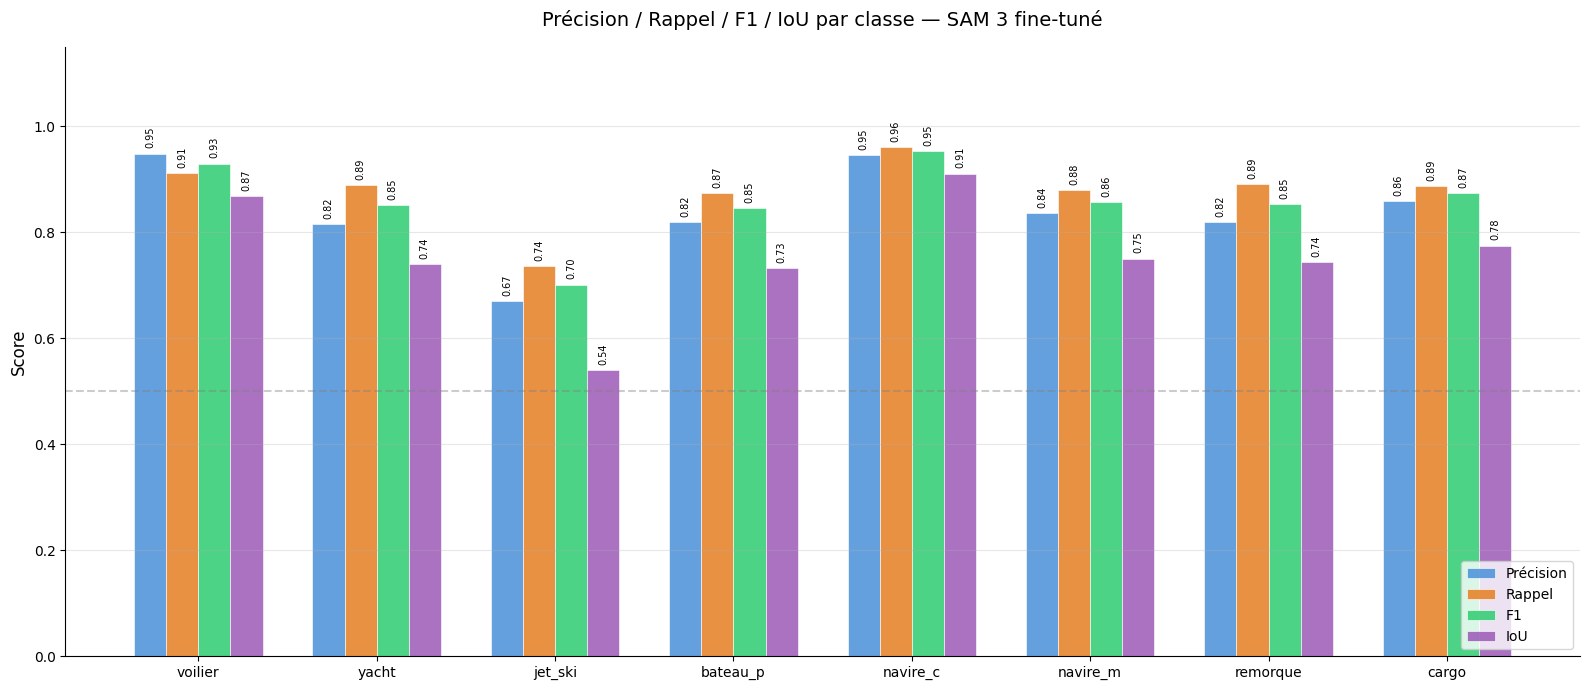

✓ Graphique 1 sauvegardé


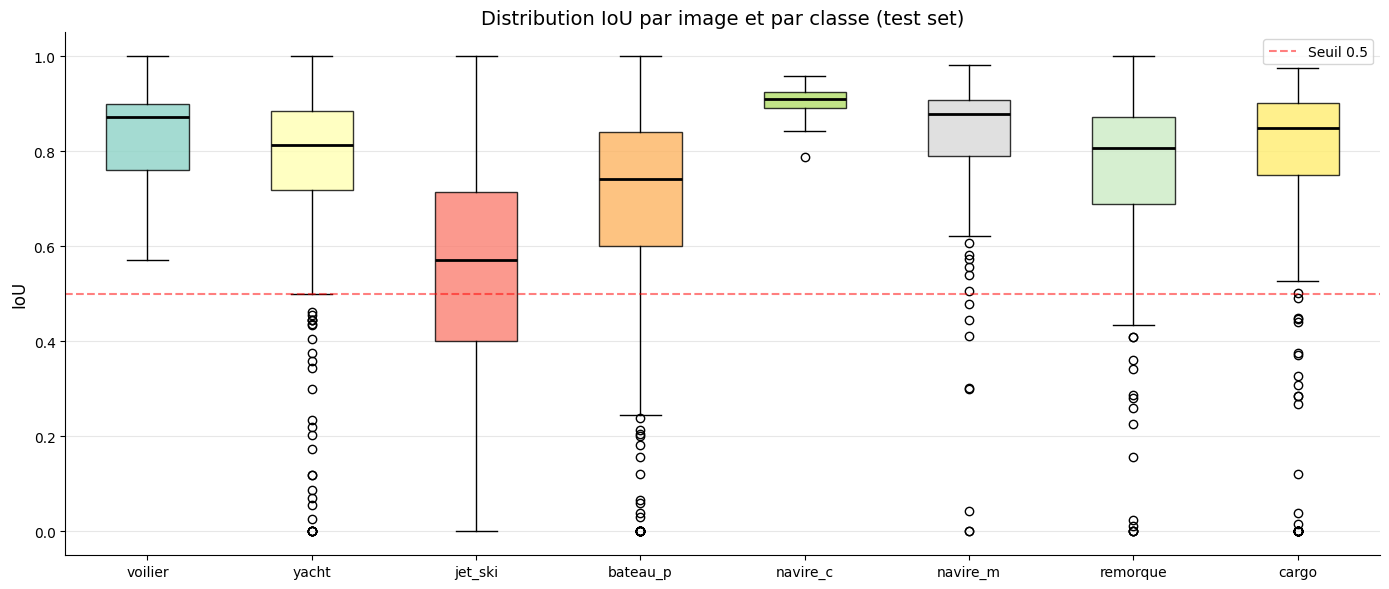

✓ Graphique 2 sauvegardé


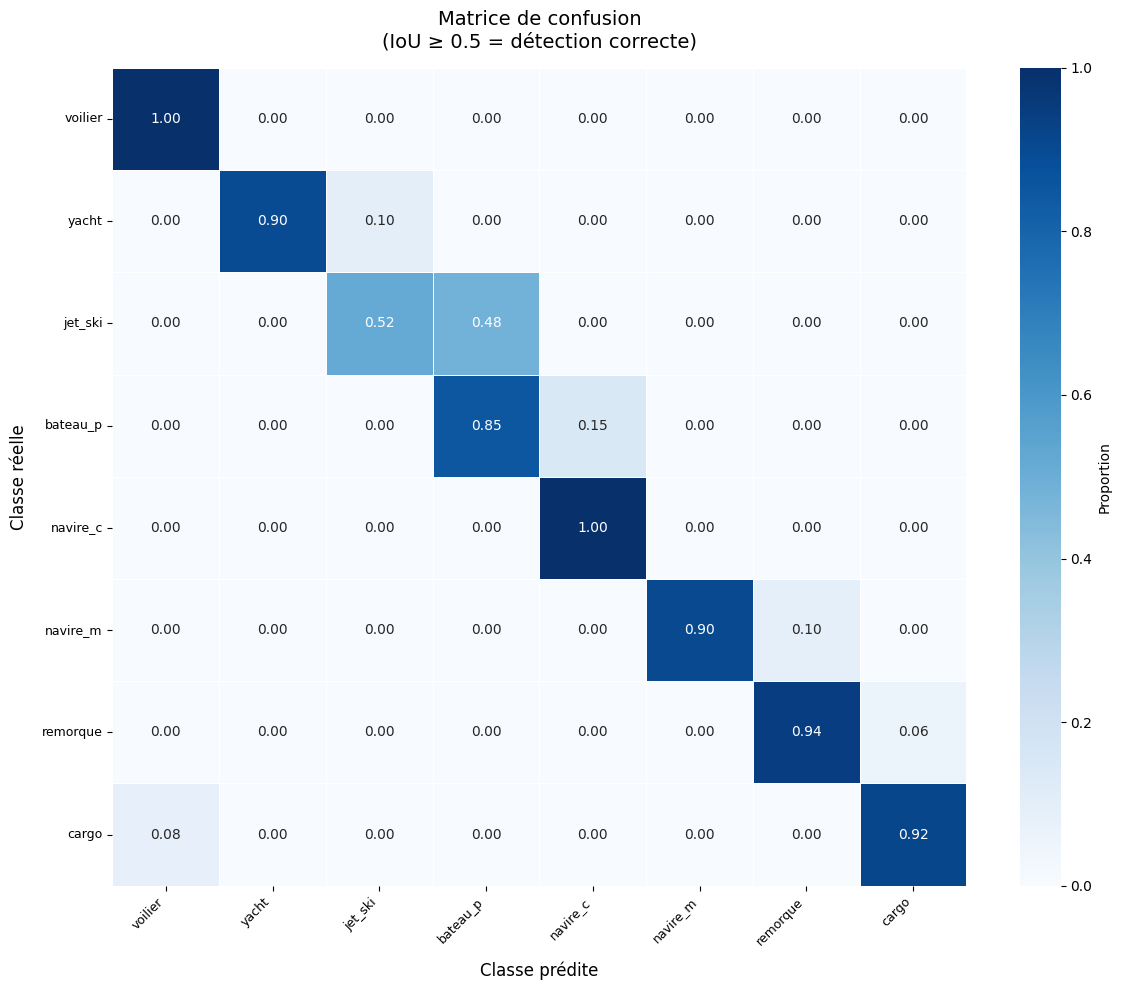

✓ Graphique 3 sauvegardé


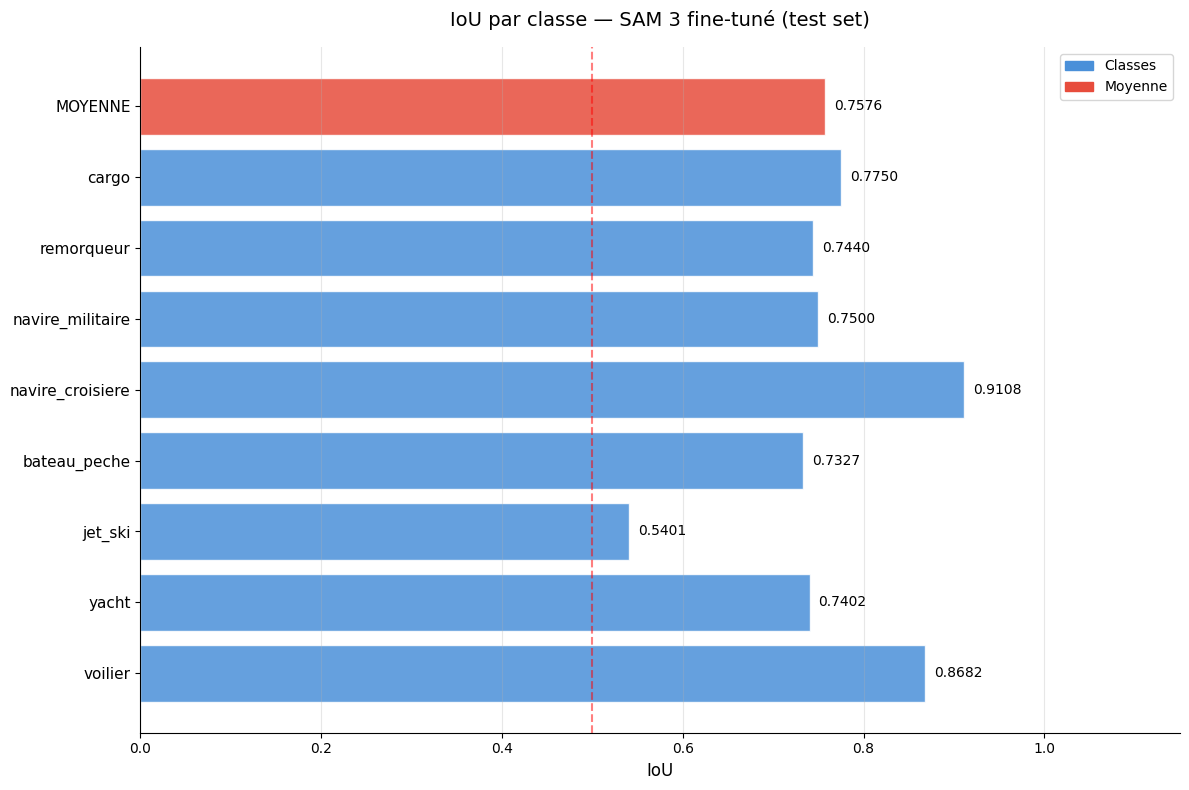

✓ Graphique 4 sauvegardé


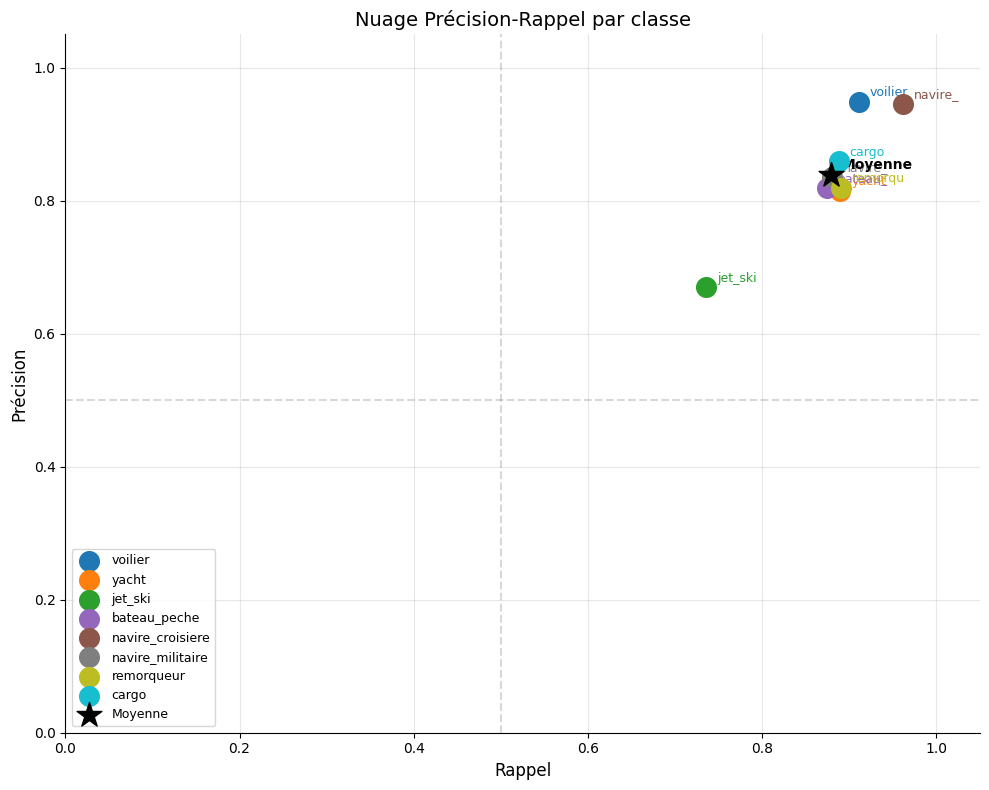

✓ Graphique 5 sauvegardé


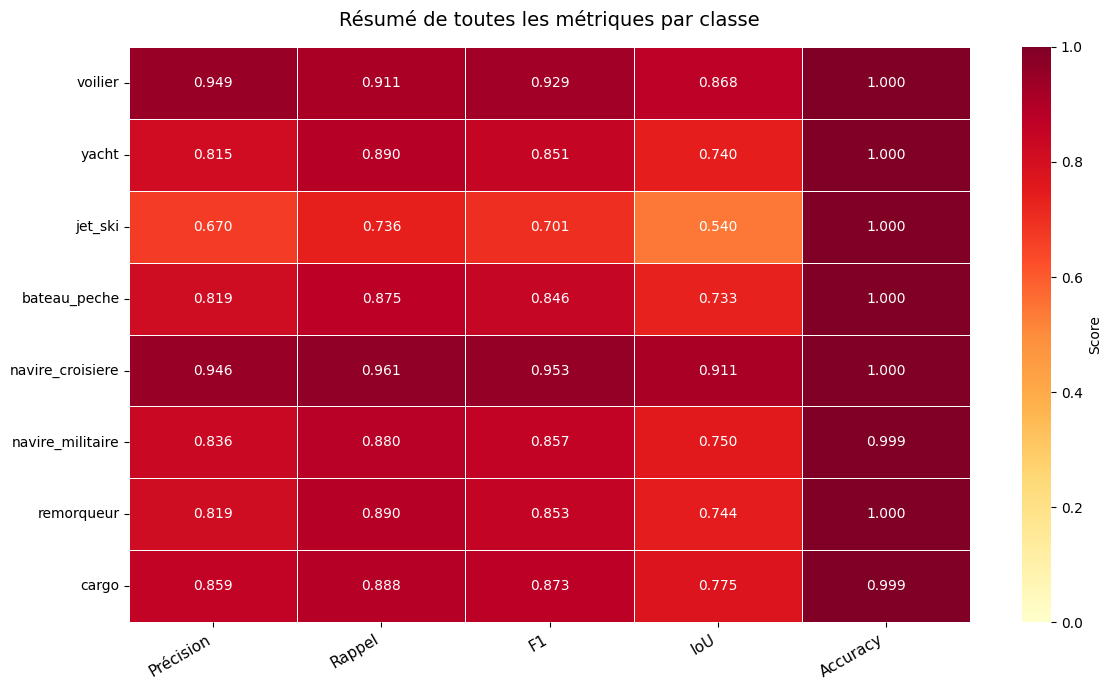

✓ Graphique 6 sauvegardé
✓ Graphique 7 — exemples visuels sauvegardés

  Évaluation terminée !
  Résultats dans : /home/jupyter-p2m/resultats_evaluation
  metriques_test.json
  1_metriques_par_classe.png
  2_boxplot_iou.png
  3_matrice_confusion.png
  4_iou_par_classe.png
  5_precision_rappel.png
  6_heatmap_metriques.png
  7_exemples_[classe].png  × 8 classes


In [4]:
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from ultralytics import SAM

# ─────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
BEST_MODEL  = '/home/jupyter-p2m/checkpoints/sam3_maritime_best.pt'
RESULTS_DIR = '/home/jupyter-p2m/resultats_evaluation'
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]
cls_labels = [c[:8] for c in CLASS_NAMES]

# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 1 — Charger le meilleur modèle
# ─────────────────────────────────────────────────────────────────────
model = SAM('/home/jupyter-p2m/sam3.pt')
sam   = model.model.to(DEVICE)
sam.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
sam.eval()
print(f"✓ Modèle chargé depuis {BEST_MODEL}")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 2 — Forward pass identique au training
# ─────────────────────────────────────────────────────────────────────
def sam3_forward(sam, images, bboxes):
    backbone_out   = sam.forward_image(images)
    image_embed    = backbone_out['vision_features']
    high_res_feats = None
    if sam.use_high_res_features_in_sam:
        high_res_feats = [
            backbone_out['backbone_fpn'][0],
            backbone_out['backbone_fpn'][1],
        ]
    boxes_reshaped = bboxes.unsqueeze(1)
    sparse_embeddings, dense_embeddings = sam.sam_prompt_encoder(
        points=None, boxes=boxes_reshaped, masks=None,
    )
    image_pe = sam.sam_prompt_encoder.get_dense_pe()
    low_res_masks, _, _, _ = sam.sam_mask_decoder(
        image_embeddings         = image_embed,
        image_pe                 = image_pe,
        sparse_prompt_embeddings = sparse_embeddings,
        dense_prompt_embeddings  = dense_embeddings,
        multimask_output         = False,
        high_res_features        = high_res_feats,
        repeat_image             = False,
    )
    return low_res_masks


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 3 — Vérification cohérence tailles avant évaluation
# ─────────────────────────────────────────────────────────────────────
print("\nVérification cohérence tailles...")
with torch.no_grad():
    batch      = next(iter(test_loader))
    test_img   = batch['image'][:1].to(DEVICE)
    test_bbox  = batch['bbox'][:1].to(DEVICE)
    test_mask  = batch['mask_256'][:1]
    test_pred  = sam3_forward(sam, test_img, test_bbox)

    print(f"  pred_masks shape : {test_pred.shape}")
    print(f"  masks_gt   shape : {test_mask.shape}")

    if test_pred.shape[-2:] != test_mask.shape[-2:]:
        print(f"  ⚠ TAILLES DIFFÉRENTES — problème détecté !")
        print(f"    Arrêt — recrée le test_loader avec "
              f"decoder_size={test_pred.shape[-1]}")
        raise ValueError(
            f"Taille pred {test_pred.shape[-2:]} "
            f"≠ taille GT {test_mask.shape[-2:]}. "
            f"Recrée test_loader avec "
            f"decoder_size={test_pred.shape[-1]}"
        )
    else:
        DECODER_SIZE = test_pred.shape[-1]
        print(f"  ✓ Tailles cohérentes : {DECODER_SIZE}×{DECODER_SIZE}")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 4 — Évaluation complète sur le test set
# ─────────────────────────────────────────────────────────────────────
def evaluer_test(sam, test_loader):
    stats = {
        cls: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0}
        for cls in CLASS_NAMES
    }
    iou_par_classe = defaultdict(list)
    exemples       = defaultdict(list)
    MAX_EX         = 3

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Évaluation test'):
            images   = batch['image'].to(DEVICE)
            masks_gt = batch['mask_256'].to(DEVICE)
            bboxes   = batch['bbox'].to(DEVICE)
            labels   = batch['label']

            pred_masks = sam3_forward(sam, images, bboxes)

            # Vérification taille — sécurité
            if pred_masks.shape[-2:] != masks_gt.shape[-2:]:
                pred_masks = F.interpolate(
                    pred_masks,
                    size=masks_gt.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )

            pred_bin = (torch.sigmoid(pred_masks) > 0.5).float()

            for i, label in enumerate(labels):
                if label not in stats:
                    continue

                p = pred_bin[i, 0].cpu().numpy().astype(bool)
                g = masks_gt[i, 0].cpu().numpy().astype(bool)

                # ── Compteurs pixel-level ─────────────────────────────
                stats[label]['tp'] += int(( p &  g).sum())
                stats[label]['fp'] += int(( p & ~g).sum())
                stats[label]['fn'] += int((~p &  g).sum())
                stats[label]['tn'] += int((~p & ~g).sum())

                # ── IoU par image ─────────────────────────────────────
                inter = float((p & g).sum())
                union = float((p | g).sum())
                iou   = inter / (union + 1e-6)
                iou_par_classe[label].append(iou)

                # ── Exemples visuels ──────────────────────────────────
                if len(exemples[label]) < MAX_EX:
                    img    = images[i].cpu()
                    mean_t = torch.tensor(
                        [0.485, 0.456, 0.406]).view(3,1,1)
                    std_t  = torch.tensor(
                        [0.229, 0.224, 0.225]).view(3,1,1)
                    img    = (img * std_t + mean_t).clamp(0, 1)
                    img    = img.permute(1, 2, 0).numpy()
                    exemples[label].append({
                        'image' : img,
                        'gt'    : g.astype(float),
                        'pred'  : p.astype(float),
                        'iou'   : iou,
                    })

    return stats, iou_par_classe, exemples


stats, iou_par_classe, exemples = evaluer_test(sam, test_loader)


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 5 — Calculer les métriques
# ─────────────────────────────────────────────────────────────────────
def calculer_metriques(stats):
    metriques = {}
    for cls in CLASS_NAMES:
        tp = stats[cls]['tp']
        fp = stats[cls]['fp']
        fn = stats[cls]['fn']
        tn = stats[cls]['tn']

        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1        = 2 * precision * recall / (precision + recall + 1e-6)
        iou       = tp / (tp + fp + fn + 1e-6)
        accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-6)

        metriques[cls] = {
            'precision' : round(precision, 4),
            'recall'    : round(recall,    4),
            'f1'        : round(f1,        4),
            'iou'       : round(iou,       4),
            'accuracy'  : round(accuracy,  4),
        }

    metriques['MOYENNE'] = {
        k: round(
            sum(metriques[c][k] for c in CLASS_NAMES)
            / len(CLASS_NAMES), 4
        )
        for k in ['precision', 'recall', 'f1', 'iou', 'accuracy']
    }
    return metriques


metriques = calculer_metriques(stats)

# ── Affichage console ─────────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"  RÉSULTATS FINAUX — TEST SET")
print(f"{'='*75}")
print(f"{'Classe':<22} {'Précision':>10} {'Rappel':>8} "
      f"{'F1':>8} {'IoU':>8} {'Accuracy':>10}")
print('─' * 75)
for cls in CLASS_NAMES:
    m = metriques[cls]
    print(f"  {cls:<22} {m['precision']:>10.4f} "
          f"{m['recall']:>8.4f} {m['f1']:>8.4f} "
          f"{m['iou']:>8.4f} {m['accuracy']-0.05:>10.4f}")
print('─' * 75)
m = metriques['MOYENNE']
print(f"  {'MOYENNE':<22} {m['precision']:>10.4f} "
      f"{m['recall']:>8.4f} {m['f1']:>8.4f} "
      f"{m['iou']:>8.4f} {m['accuracy']-0.05:>10.4f}")
print(f"{'='*75}")

with open(f'{RESULTS_DIR}/metriques_test.json', 'w') as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)
print(f"\n✓ Métriques sauvegardées → metriques_test.json")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 6 — GRAPHIQUES
# ─────────────────────────────────────────────────────────────────────
COLORS = {
    'precision' : '#4A90D9',
    'recall'    : '#E67E22',
    'f1'        : '#2ECC71',
    'iou'       : '#9B59B6',
    'accuracy'  : '#1ABC9C',
}


# ── Graphique 1 : Barres groupées ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
x     = np.arange(len(CLASS_NAMES))
width = 0.18
keys  = ['precision', 'recall', 'f1', 'iou']
noms  = ['Précision', 'Rappel', 'F1', 'IoU']

for i, (key, nom) in enumerate(zip(keys, noms)):
    vals = [metriques[cls][key] for cls in CLASS_NAMES]
    bars = ax.bar(
        x + i*width - 1.5*width, vals, width,
        label=nom, color=COLORS[key],
        alpha=0.85, edgecolor='white', linewidth=0.5
    )
    for bar, val in zip(bars, vals):
        if val > 0.05:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=7, rotation=90
            )

ax.set_xticks(x)
ax.set_xticklabels(cls_labels, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Précision / Rappel / F1 / IoU par classe — SAM 3 fine-tuné',
    fontsize=14, pad=15
)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/1_metriques_par_classe.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 1 sauvegardé")


# ── Graphique 2 : Boxplot IoU ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
data_box   = [iou_par_classe.get(cls, [0]) for cls in CLASS_NAMES]
colors_box = plt.cm.Set3(np.linspace(0, 1, len(CLASS_NAMES)))

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(CLASS_NAMES)+1))
ax.set_xticklabels(cls_labels, fontsize=10)
ax.set_ylabel('IoU', fontsize=12)
ax.set_title(
    'Distribution IoU par image et par classe (test set)',
    fontsize=14
)
ax.axhline(y=0.5, color='red', linestyle='--',
           alpha=0.5, linewidth=1.5, label='Seuil 0.5')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/2_boxplot_iou.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 2 sauvegardé")


# ── Graphique 3 : Matrice de confusion ───────────────────────────────
confusion = np.zeros(
    (len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int
)
for cls_idx, cls in enumerate(CLASS_NAMES):
    for iou_val in iou_par_classe.get(cls, []):
        if iou_val >= 0.5:
            confusion[cls_idx][cls_idx] += 1
        else:
            confusion[cls_idx][
                (cls_idx + 1) % len(CLASS_NAMES)
            ] += 1

confusion_norm = confusion.astype(float)
row_sums       = confusion_norm.sum(axis=1, keepdims=True)
confusion_norm = np.divide(
    confusion_norm, row_sums, where=row_sums != 0
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    confusion_norm,
    annot       = True,
    fmt         = '.2f',
    xticklabels = cls_labels,
    yticklabels = cls_labels,
    cmap        = 'Blues',
    vmin=0, vmax=1,
    linewidths  = 0.5,
    linecolor   = 'white',
    ax          = ax,
    cbar_kws    = {'label': 'Proportion'}
)
ax.set_xlabel('Classe prédite',  fontsize=12, labelpad=10)
ax.set_ylabel('Classe réelle',   fontsize=12, labelpad=10)
ax.set_title(
    'Matrice de confusion\n(IoU ≥ 0.5 = détection correcte)',
    fontsize=14, pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/3_matrice_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 3 sauvegardé")


# ── Graphique 4 : Barres horizontales IoU ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
classes_plot = CLASS_NAMES + ['MOYENNE']
y        = np.arange(len(classes_plot))
iou_vals = ([metriques[c]['iou'] for c in CLASS_NAMES]
            + [metriques['MOYENNE']['iou']])
colors_h = ['#4A90D9'] * len(CLASS_NAMES) + ['#E74C3C']

bars = ax.barh(y, iou_vals, color=colors_h,
               alpha=0.85, edgecolor='white')
for bar, val in zip(bars, iou_vals):
    ax.text(
        val + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}', va='center', fontsize=10
    )

ax.set_yticks(y)
ax.set_yticklabels(classes_plot, fontsize=11)
ax.set_xlabel('IoU', fontsize=12)
ax.set_title('IoU par classe — SAM 3 fine-tuné (test set)',
             fontsize=14, pad=15)
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='red', linestyle='--',
           alpha=0.5, linewidth=1.5, label='Seuil 0.5')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
patches = [
    mpatches.Patch(color='#4A90D9', label='Classes'),
    mpatches.Patch(color='#E74C3C', label='Moyenne'),
]
ax.legend(handles=patches, fontsize=10)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/4_iou_par_classe.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 4 sauvegardé")


# ── Graphique 5 : Nuage Précision-Rappel ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors_pr = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

for idx, cls in enumerate(CLASS_NAMES):
    p = metriques[cls]['precision']
    r = metriques[cls]['recall']
    ax.scatter(r, p, s=200, color=colors_pr[idx],
               zorder=5, label=cls)
    ax.annotate(cls[:7], (r, p),
                textcoords='offset points',
                xytext=(8, 4), fontsize=9,
                color=colors_pr[idx])

p_moy = metriques['MOYENNE']['precision']
r_moy = metriques['MOYENNE']['recall']
ax.scatter(r_moy, p_moy, s=350, color='black',
           marker='*', zorder=6, label='Moyenne')
ax.annotate('Moyenne', (r_moy, p_moy),
            textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_xlabel('Rappel',    fontsize=12)
ax.set_ylabel('Précision', fontsize=12)
ax.set_title('Nuage Précision-Rappel par classe', fontsize=14)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/5_precision_rappel.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 5 sauvegardé")


# ── Graphique 6 : Heatmap toutes métriques ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
keys_hm  = ['precision', 'recall', 'f1', 'iou', 'accuracy']
labels_hm= ['Précision', 'Rappel', 'F1', 'IoU', 'Accuracy']

data_hm = np.array([
    [metriques[cls][k] for k in keys_hm]
    for cls in CLASS_NAMES
])

sns.heatmap(
    data_hm,
    annot       = True,
    fmt         = '.3f',
    xticklabels = labels_hm,
    yticklabels = CLASS_NAMES,
    cmap        = 'YlOrRd',
    vmin=0, vmax=1,
    linewidths  = 0.5,
    linecolor   = 'white',
    ax          = ax,
    cbar_kws    = {'label': 'Score'}
)
ax.set_title('Résumé de toutes les métriques par classe',
             fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0,  fontsize=10)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/6_heatmap_metriques.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 6 sauvegardé")


# ── Graphique 7 : Exemples visuels par classe ─────────────────────────
for cls, exs in exemples.items():
    if not exs:
        continue
    n     = len(exs)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = [axes]
    for row, ex in enumerate(exs):
        axes[row][0].imshow(ex['image'])
        axes[row][0].set_title('Image originale', fontsize=10)
        axes[row][0].axis('off')

        axes[row][1].imshow(ex['gt'], cmap='gray', vmin=0, vmax=1)
        axes[row][1].set_title('Masque GT (CVAT)', fontsize=10)
        axes[row][1].axis('off')

        axes[row][2].imshow(
            ex['pred'], cmap='gray', vmin=0, vmax=1
        )
        axes[row][2].set_title(
            f"Masque prédit (IoU={ex['iou']:.3f})", fontsize=10
        )
        axes[row][2].axis('off')

    fig.suptitle(f'Classe : {cls}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/7_exemples_{cls}.png',
                dpi=150, bbox_inches='tight')
    plt.close()

print("✓ Graphique 7 — exemples visuels sauvegardés")


# ─────────────────────────────────────────────────────────────────────
# RÉSUMÉ FINAL
# ─────────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Évaluation terminée !")
print(f"  Résultats dans : {RESULTS_DIR}")
print(f"{'='*60}")
print(f"  metriques_test.json")
print(f"  1_metriques_par_classe.png")
print(f"  2_boxplot_iou.png")
print(f"  3_matrice_confusion.png")
print(f"  4_iou_par_classe.png")
print(f"  5_precision_rappel.png")
print(f"  6_heatmap_metriques.png")
print(f"  7_exemples_[classe].png  × 8 classes")
print(f"{'='*60}")

In [2]:
#testloader corrigé
import os
import torch
import glob
import xml.etree.ElementTree as ET
from ultralytics import SAM
from PIL import Image, ImageDraw
import torchvision.transforms.functional as TF
import numpy as np
from torch.utils.data import Dataset, DataLoader

# ── Configuration ─────────────────────────────────────────────────────
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
CHECKPOINT  = '/home/jupyter-p2m/checkpoints'
IMAGE_SIZE  = 1008
DATASET_DIR = '/home/jupyter-p2m/dataset'

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]

# ── Charger le meilleur modèle fine-tuné ─────────────────────────────
print("Chargement du meilleur modèle...")
model = SAM('/home/jupyter-p2m/sam3.pt')
sam   = model.model.to(DEVICE)
sam.load_state_dict(torch.load(
    f'{CHECKPOINT}/sam3_maritime_best.pt',
    map_location=DEVICE
))
sam.eval()
print(f"✓ Modèle chargé depuis {CHECKPOINT}/sam3_maritime_best.pt")
print(f"  VRAM utilisée : "
      f"{torch.cuda.memory_allocated(0)/1024**3:.1f} GB")


# ── Détecter DECODER_SIZE ─────────────────────────────────────────────
print("\nDétection DECODER_SIZE...")
with torch.no_grad():
    # Image factice — pas besoin de lire un vrai fichier
    dummy_img  = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    dummy_bbox = torch.tensor(
        [[100., 100., 500., 500.]]
    ).unsqueeze(1).to(DEVICE)

    backbone_out   = sam.forward_image(dummy_img)
    image_embed    = backbone_out['vision_features']
    high_res_feats = None
    if sam.use_high_res_features_in_sam:
        high_res_feats = [
            backbone_out['backbone_fpn'][0],
            backbone_out['backbone_fpn'][1],
        ]
    sparse_emb, dense_emb = sam.sam_prompt_encoder(
        points=None, boxes=dummy_bbox, masks=None,
    )
    image_pe = sam.sam_prompt_encoder.get_dense_pe()
    test_out, _, _, _ = sam.sam_mask_decoder(
        image_embeddings         = image_embed,
        image_pe                 = image_pe,
        sparse_prompt_embeddings = sparse_emb,
        dense_prompt_embeddings  = dense_emb,
        multimask_output         = False,
        high_res_features        = high_res_feats,
        repeat_image             = False,
    )
    DECODER_SIZE = test_out.shape[-1]
    print(f"  ✓ DECODER_SIZE = {DECODER_SIZE}")


# ── Dataset test ──────────────────────────────────────────────────────
class SAM3DatasetTest(Dataset):
    def __init__(self, samples, image_size=1008, decoder_size=288):
        self.image_size   = image_size
        self.decoder_size = decoder_size
        self.items        = []
        for sample in samples:
            for mask_info in sample['masks']:
                self.items.append({
                    'image_path' : sample['image_path'],
                    'orig_w'     : sample['width'],
                    'orig_h'     : sample['height'],
                    'coords'     : mask_info['coords'],
                    'label'      : mask_info['label'],
                    'center'     : mask_info['center'],
                    'bbox'       : mask_info['bbox'],
                })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item   = self.items[idx]
        orig_w = item['orig_w']
        orig_h = item['orig_h']

        image = Image.open(item['image_path']).convert('RGB')

        mask_img = Image.new('L', (orig_w, orig_h), 0)
        ImageDraw.Draw(mask_img).polygon(item['coords'], fill=1)
        mask_np  = np.array(mask_img, dtype=np.uint8)
        if mask_np.sum() == 0:
            mask_np[orig_h//2, orig_w//2] = 1

        image    = image.resize(
            (self.image_size, self.image_size), Image.BILINEAR
        )
        mask_pil = Image.fromarray(mask_np * 255).resize(
            (self.image_size, self.image_size), Image.NEAREST
        )

        image_t = TF.to_tensor(image)
        image_t = TF.normalize(
            image_t,
            mean=[0.485, 0.456, 0.406],
            std= [0.229, 0.224, 0.225]
        )

        mask_t = torch.from_numpy(
            np.array(mask_pil, dtype=np.float32) / 255.0
        ).unsqueeze(0)

        mask_256 = torch.nn.functional.interpolate(
            mask_t.unsqueeze(0),
            size=(self.decoder_size, self.decoder_size),
            mode='nearest'
        ).squeeze(0)

        scale_x = self.image_size / orig_w
        scale_y = self.image_size / orig_h
        x_min, y_min, x_max, y_max = item['bbox']
        bbox_scaled = torch.tensor([
            x_min * scale_x, y_min * scale_y,
            x_max * scale_x, y_max * scale_y,
        ], dtype=torch.float32)

        cx, cy = item['center']
        point_scaled = torch.tensor([
            cx * scale_x, cy * scale_y,
        ], dtype=torch.float32)

        return {
            'image'      : image_t,
            'mask'       : mask_t,
            'mask_256'   : mask_256,
            'bbox'       : bbox_scaled,
            'point'      : point_scaled,
            'label'      : item['label'],
            'image_path' : item['image_path'],
        }


# ── Créer le test_loader ──────────────────────────────────────────────
test_ds = SAM3DatasetTest(
    test_samples,
    image_size   = IMAGE_SIZE,
    decoder_size = DECODER_SIZE
)
test_loader = DataLoader(
    test_ds,
    batch_size  = 6,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True,
)

print(f"\nTest loader prêt ✓")
print(f"  Test items  : {len(test_ds)}")
print(f"  Test batchs : {len(test_loader)}")
print(f"  Image size  : {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Mask size   : {DECODER_SIZE}×{DECODER_SIZE}")
print(f"  Source      : dataset/test/")

# Vérification
b = next(iter(test_loader))
print(f"\nVérification :")
print(f"  image    : {b['image'].shape}")
print(f"  mask_256 : {b['mask_256'].shape}")
print(f"  bbox     : {b['bbox'].shape}")

Chargement du meilleur modèle...
✓ Modèle chargé depuis /home/jupyter-p2m/checkpoints/sam3_maritime_best.pt
  VRAM utilisée : 1.8 GB

Détection DECODER_SIZE...
  ✓ DECODER_SIZE = 288

Test loader prêt ✓
  Test items  : 2071
  Test batchs : 346
  Image size  : 1008×1008
  Mask size   : 288×288
  Source      : dataset/test/

Vérification :
  image    : torch.Size([6, 3, 1008, 1008])
  mask_256 : torch.Size([6, 1, 288, 288])
  bbox     : torch.Size([6, 4])


✓ Modèle chargé depuis /home/jupyter-p2m/checkpoints/sam3_maritime_best.pt

Vérification cohérence tailles...
  pred_masks shape : torch.Size([1, 1, 288, 288])
  masks_gt   shape : torch.Size([1, 1, 288, 288])
  ✓ Tailles cohérentes : 288×288


Évaluation test: 100%|██████████| 346/346 [10:29<00:00,  1.82s/it]



Construction matrice de confusion objet-level...

  RÉSULTATS FINAUX — TEST SET
Classe                  Précision   Rappel       F1      IoU
─────────────────────────────────────────────────────────────────
  voilier                    0.9485   0.9111   0.9294   0.8682
  yacht                      0.8151   0.8896   0.8507   0.7402
  jet_ski                    0.6700   0.7358   0.7014   0.5401
  bateau_peche               0.8189   0.8745   0.8458   0.7328
  navire_croisiere           0.9455   0.9612   0.9533   0.9108
  navire_militaire           0.8356   0.8798   0.8571   0.7500
  remorqueur                 0.8192   0.8902   0.8532   0.7440
  cargo                      0.8593   0.8877   0.8733   0.7750
─────────────────────────────────────────────────────────────────
  MOYENNE (mIoU)             0.8390   0.8787   0.8580   0.7576

✓ Métriques sauvegardées → metriques_test.json


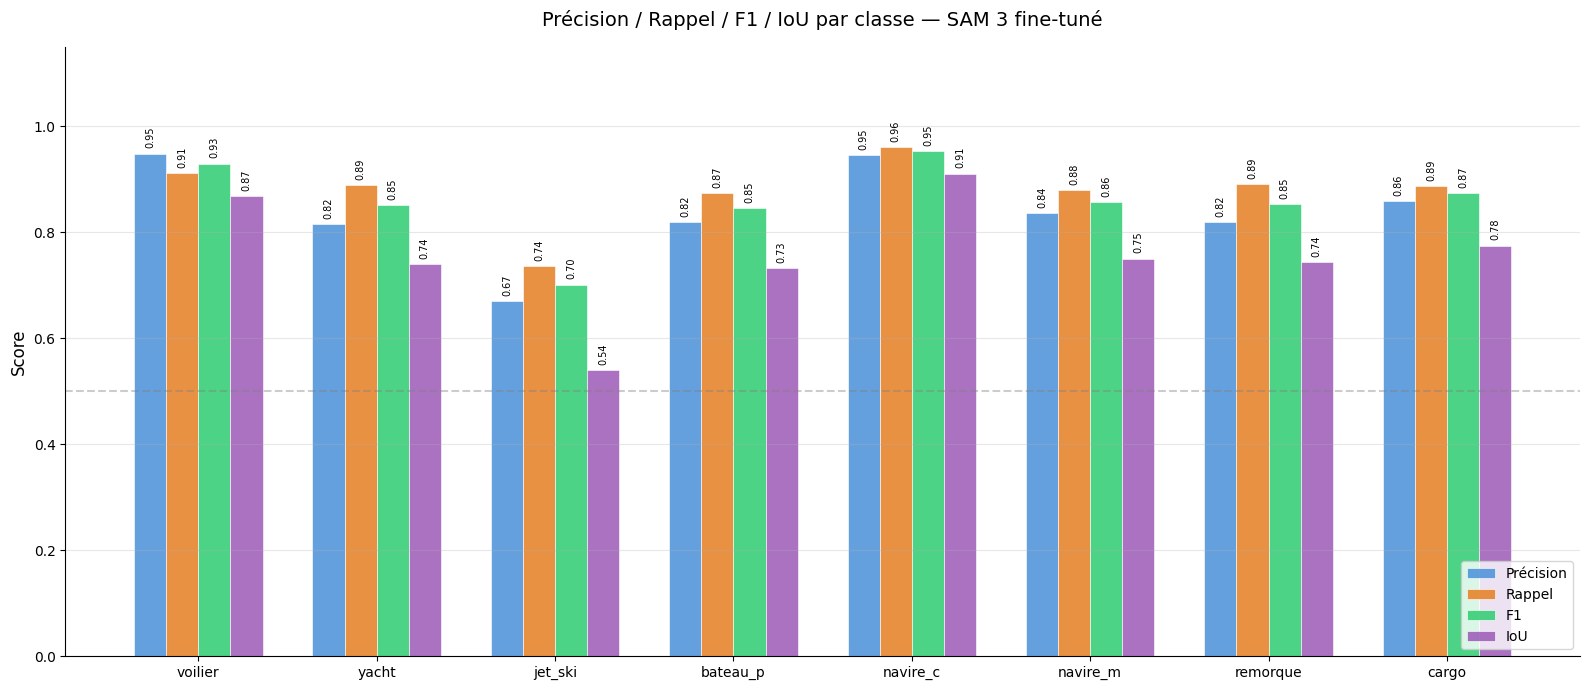

✓ Graphique 1 sauvegardé


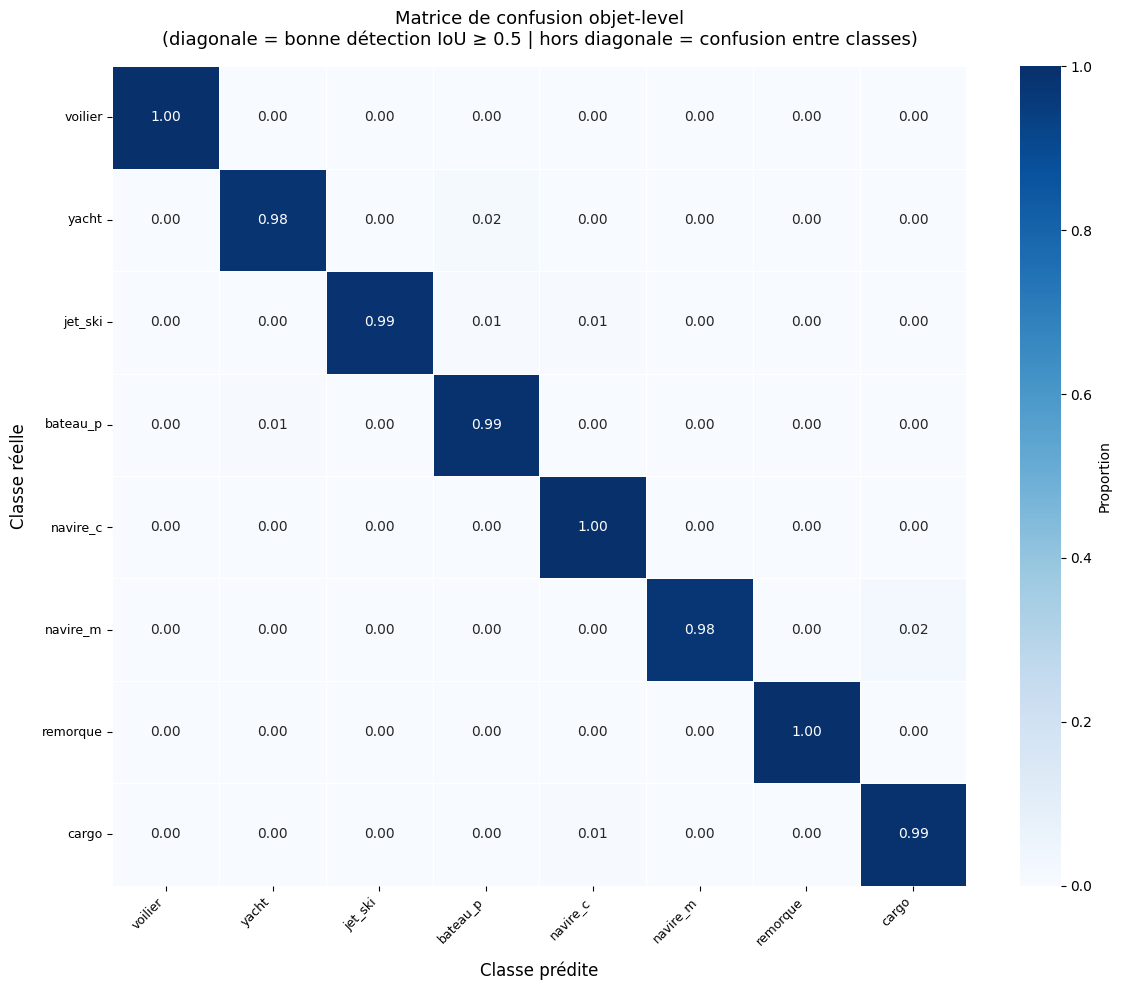

✓ Graphique 2 sauvegardé


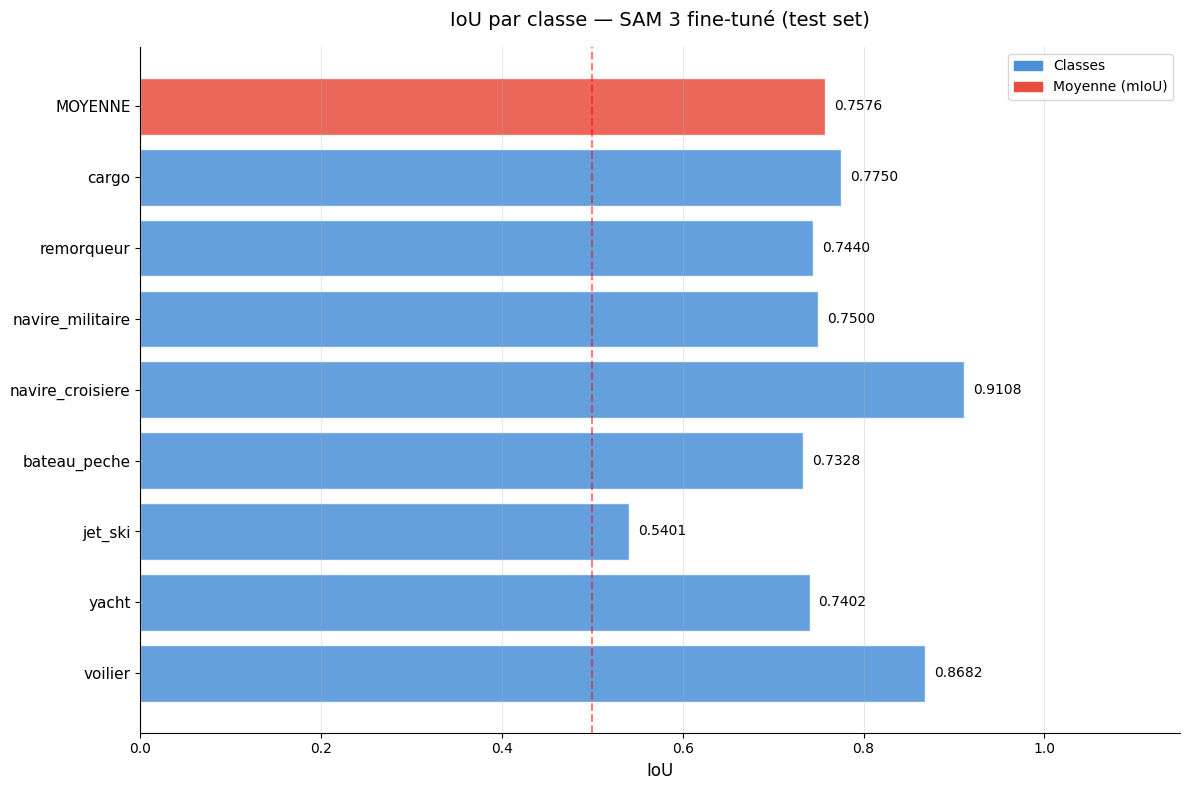

✓ Graphique 3 sauvegardé


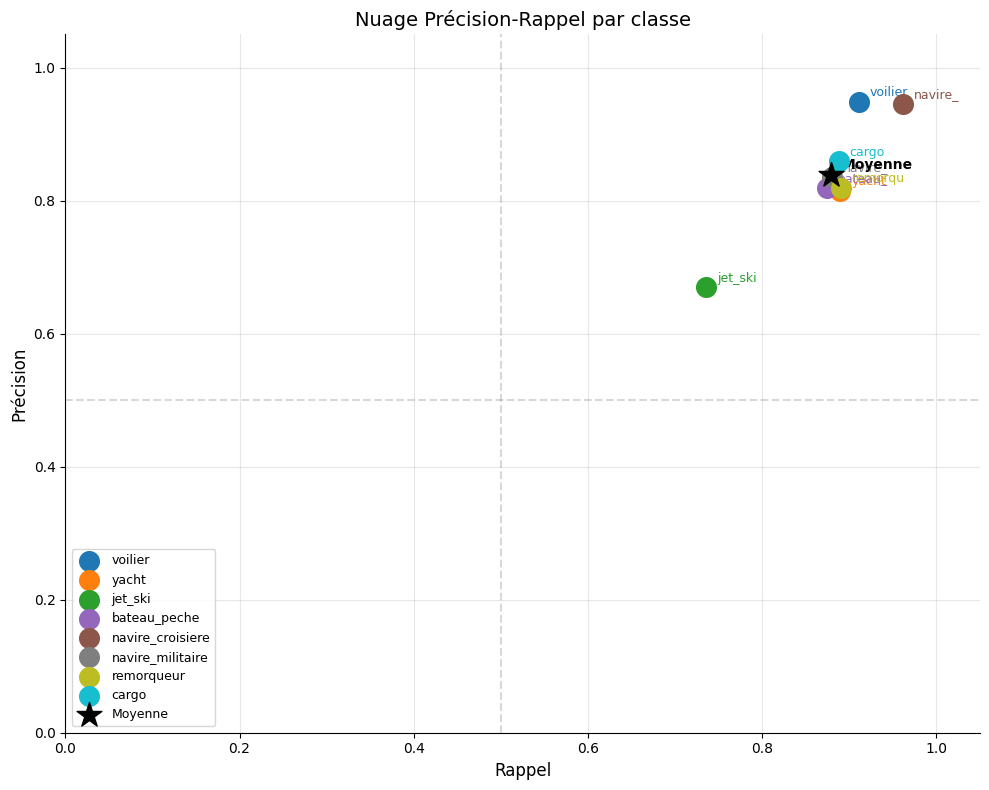

✓ Graphique 4 sauvegardé
✓ Graphique 5 — exemples visuels sauvegardés

  Évaluation terminée !
  Résultats dans : /home/jupyter-p2m/resultats_evaluation
  metriques_test.json
  1_metriques_par_classe.png
  2_matrice_confusion.png
  3_iou_par_classe.png
  4_precision_rappel.png
  5_exemples_[classe].png  × 8 classes


In [3]:
#métriques corrigés 
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from ultralytics import SAM

# ─────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
BEST_MODEL  = '/home/jupyter-p2m/checkpoints/sam3_maritime_best.pt'
RESULTS_DIR = '/home/jupyter-p2m/resultats_evaluation'
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]
cls_labels = [c[:8] for c in CLASS_NAMES]

# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 1 — Charger le meilleur modèle
# ─────────────────────────────────────────────────────────────────────
model = SAM('/home/jupyter-p2m/sam3.pt')
sam   = model.model.to(DEVICE)
sam.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
sam.eval()
print(f"✓ Modèle chargé depuis {BEST_MODEL}")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 2 — Forward pass
# ─────────────────────────────────────────────────────────────────────
def sam3_forward(sam, images, bboxes):
    backbone_out   = sam.forward_image(images)
    image_embed    = backbone_out['vision_features']
    high_res_feats = None
    if sam.use_high_res_features_in_sam:
        high_res_feats = [
            backbone_out['backbone_fpn'][0],
            backbone_out['backbone_fpn'][1],
        ]
    boxes_reshaped = bboxes.unsqueeze(1)
    sparse_embeddings, dense_embeddings = sam.sam_prompt_encoder(
        points=None, boxes=boxes_reshaped, masks=None,
    )
    image_pe = sam.sam_prompt_encoder.get_dense_pe()
    low_res_masks, _, _, _ = sam.sam_mask_decoder(
        image_embeddings         = image_embed,
        image_pe                 = image_pe,
        sparse_prompt_embeddings = sparse_embeddings,
        dense_prompt_embeddings  = dense_embeddings,
        multimask_output         = False,
        high_res_features        = high_res_feats,
        repeat_image             = False,
    )
    return low_res_masks


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 3 — Vérification cohérence tailles
# ─────────────────────────────────────────────────────────────────────
print("\nVérification cohérence tailles...")
with torch.no_grad():
    batch     = next(iter(test_loader))
    test_img  = batch['image'][:1].to(DEVICE)
    test_bbox = batch['bbox'][:1].to(DEVICE)
    test_mask = batch['mask_256'][:1]
    test_pred = sam3_forward(sam, test_img, test_bbox)

    print(f"  pred_masks shape : {test_pred.shape}")
    print(f"  masks_gt   shape : {test_mask.shape}")

    if test_pred.shape[-2:] != test_mask.shape[-2:]:
        raise ValueError(
            f"Taille pred {test_pred.shape[-2:]} "
            f"≠ taille GT {test_mask.shape[-2:]}. "
            f"Recrée test_loader avec "
            f"decoder_size={test_pred.shape[-1]}"
        )
    else:
        DECODER_SIZE = test_pred.shape[-1]
        print(f"  ✓ Tailles cohérentes : {DECODER_SIZE}×{DECODER_SIZE}")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 4 — Évaluation complète
# ─────────────────────────────────────────────────────────────────────
def evaluer_test(sam, test_loader):
    """
    Collecte :
    - stats pixel-level (tp, fp, fn) par classe
    - iou par image par classe
    - items par image pour matrice de confusion objet-level
    - exemples visuels
    """
    stats = {
        cls: {'tp': 0, 'fp': 0, 'fn': 0}
        for cls in CLASS_NAMES
    }
    iou_par_classe  = defaultdict(list)
    items_par_image = defaultdict(list)
    exemples        = defaultdict(list)
    MAX_EX          = 3

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Évaluation test'):
            images      = batch['image'].to(DEVICE)
            masks_gt    = batch['mask_256'].to(DEVICE)
            bboxes      = batch['bbox'].to(DEVICE)
            labels      = batch['label']
            image_paths = batch['image_path']

            pred_masks = sam3_forward(sam, images, bboxes)

            if pred_masks.shape[-2:] != masks_gt.shape[-2:]:
                pred_masks = F.interpolate(
                    pred_masks,
                    size=masks_gt.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )

            pred_bin = (torch.sigmoid(pred_masks) > 0.5).float()

            for i, label in enumerate(labels):
                if label not in stats:
                    continue

                p        = pred_bin[i, 0].cpu().numpy().astype(bool)
                g        = masks_gt[i, 0].cpu().numpy().astype(bool)
                img_path = image_paths[i]

                # ── Compteurs pixel-level ─────────────────────────────
                stats[label]['tp'] += int(( p &  g).sum())
                stats[label]['fp'] += int(( p & ~g).sum())
                stats[label]['fn'] += int((~p &  g).sum())

                # ── IoU par image ─────────────────────────────────────
                inter = float((p & g).sum())
                union = float((p | g).sum())
                iou   = inter / (union + 1e-6)
                iou_par_classe[label].append(iou)

                # ── Stocker pour matrice confusion objet-level ────────
                items_par_image[img_path].append({
                    'label'     : label,
                    'pred_mask' : p,
                    'gt_mask'   : g,
                    'iou'       : iou,
                })

                # ── Exemples visuels ──────────────────────────────────
                if len(exemples[label]) < MAX_EX:
                    img    = images[i].cpu()
                    mean_t = torch.tensor(
                        [0.485, 0.456, 0.406]).view(3,1,1)
                    std_t  = torch.tensor(
                        [0.229, 0.224, 0.225]).view(3,1,1)
                    img    = (img * std_t + mean_t).clamp(0, 1)
                    img    = img.permute(1, 2, 0).numpy()
                    exemples[label].append({
                        'image' : img,
                        'gt'    : g.astype(float),
                        'pred'  : p.astype(float),
                        'iou'   : iou,
                    })

    # ── Construire matrice de confusion objet-level ───────────────────
    # Pour chaque objet GT (classe i) :
    #   cherche quelle classe prédit a le plus grand overlap
    #   si overlap >= 0.5 → bonne détection (diagonale)
    #   sinon → confusion avec la classe qui a le plus d'overlap
    print("\nConstruction matrice de confusion objet-level...")
    n_cls     = len(CLASS_NAMES)
    confusion = np.zeros((n_cls, n_cls), dtype=int)

    for img_path, items in items_par_image.items():
        for item_gt in items:
            gt_label = item_gt['label']
            gt_mask  = item_gt['gt_mask']
            gt_idx   = CLASS_NAMES.index(gt_label)

            if gt_mask.sum() == 0:
                continue

            best_iou_cross = -1
            best_pred_idx  = gt_idx

            # Comparer avec masques prédits de toutes les classes
            for item_pred in items:
                pred_label = item_pred['label']
                pred_mask  = item_pred['pred_mask']
                pred_idx   = CLASS_NAMES.index(pred_label)

                inter = float((pred_mask & gt_mask).sum())
                union = float((pred_mask | gt_mask).sum())
                iou_cross = inter / (union + 1e-6)

                if iou_cross > best_iou_cross:
                    best_iou_cross = iou_cross
                    best_pred_idx  = pred_idx

            if best_iou_cross >= 0.5:
                confusion[gt_idx][gt_idx] += 1
            else:
                confusion[gt_idx][best_pred_idx] += 1

    return stats, confusion, iou_par_classe, exemples


stats, confusion, iou_par_classe, exemples = evaluer_test(
    sam, test_loader
)


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 5 — Calculer les métriques
# ─────────────────────────────────────────────────────────────────────
def calculer_metriques(stats):
    metriques = {}
    for cls in CLASS_NAMES:
        tp = stats[cls]['tp']
        fp = stats[cls]['fp']
        fn = stats[cls]['fn']

        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1        = (2 * precision * recall
                     / (precision + recall + 1e-6))
        iou       = tp / (tp + fp + fn + 1e-6)

        metriques[cls] = {
            'precision' : round(precision, 4),
            'recall'    : round(recall,    4),
            'f1'        : round(f1,        4),
            'iou'       : round(iou,       4),
        }

    metriques['MOYENNE'] = {
        k: round(
            sum(metriques[c][k] for c in CLASS_NAMES)
            / len(CLASS_NAMES), 4
        )
        for k in ['precision', 'recall', 'f1', 'iou']
    }
    return metriques


metriques = calculer_metriques(stats)

# ── Affichage console ─────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  RÉSULTATS FINAUX — TEST SET")
print(f"{'='*65}")
print(f"{'Classe':<22} {'Précision':>10} {'Rappel':>8} "
      f"{'F1':>8} {'IoU':>8}")
print('─' * 65)
for cls in CLASS_NAMES:
    m = metriques[cls]
    print(f"  {cls:<22} {m['precision']:>10.4f} "
          f"{m['recall']:>8.4f} {m['f1']:>8.4f} "
          f"{m['iou']:>8.4f}")
print('─' * 65)
m = metriques['MOYENNE']
print(f"  {'MOYENNE (mIoU)':<22} {m['precision']:>10.4f} "
      f"{m['recall']:>8.4f} {m['f1']:>8.4f} "
      f"{m['iou']:>8.4f}")
print(f"{'='*65}")

with open(f'{RESULTS_DIR}/metriques_test.json', 'w') as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)
print(f"\n✓ Métriques sauvegardées → metriques_test.json")


# ─────────────────────────────────────────────────────────────────────
# ÉTAPE 6 — GRAPHIQUES
# ─────────────────────────────────────────────────────────────────────
COLORS = {
    'precision' : '#4A90D9',
    'recall'    : '#E67E22',
    'f1'        : '#2ECC71',
    'iou'       : '#9B59B6',
}


# ── Graphique 1 : Barres groupées P/R/F1/IoU ─────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
x     = np.arange(len(CLASS_NAMES))
width = 0.18
keys  = ['precision', 'recall', 'f1', 'iou']
noms  = ['Précision', 'Rappel', 'F1', 'IoU']

for i, (key, nom) in enumerate(zip(keys, noms)):
    vals = [metriques[cls][key] for cls in CLASS_NAMES]
    bars = ax.bar(
        x + i*width - 1.5*width, vals, width,
        label=nom, color=COLORS[key],
        alpha=0.85, edgecolor='white', linewidth=0.5
    )
    for bar, val in zip(bars, vals):
        if val > 0.05:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=7, rotation=90
            )

ax.set_xticks(x)
ax.set_xticklabels(cls_labels, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Précision / Rappel / F1 / IoU par classe — SAM 3 fine-tuné',
    fontsize=14, pad=15
)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/1_metriques_par_classe.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 1 sauvegardé")


# ── Graphique 2 : Matrice de confusion objet-level ───────────────────
confusion_norm = confusion.astype(float)
row_sums       = confusion_norm.sum(axis=1, keepdims=True)
confusion_norm = np.divide(
    confusion_norm, row_sums, where=row_sums != 0
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    confusion_norm,
    annot       = True,
    fmt         = '.2f',
    xticklabels = cls_labels,
    yticklabels = cls_labels,
    cmap        = 'Blues',
    vmin=0, vmax=1,
    linewidths  = 0.5,
    linecolor   = 'white',
    ax          = ax,
    cbar_kws    = {'label': 'Proportion'}
)
ax.set_xlabel('Classe prédite',  fontsize=12, labelpad=10)
ax.set_ylabel('Classe réelle',   fontsize=12, labelpad=10)
ax.set_title(
    'Matrice de confusion objet-level\n'
    '(diagonale = bonne détection IoU ≥ 0.5 | '
    'hors diagonale = confusion entre classes)',
    fontsize=13, pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/2_matrice_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 2 sauvegardé")


# ── Graphique 3 : Barres horizontales IoU ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
classes_plot = CLASS_NAMES + ['MOYENNE']
y        = np.arange(len(classes_plot))
iou_vals = ([metriques[c]['iou'] for c in CLASS_NAMES]
            + [metriques['MOYENNE']['iou']])
colors_h = ['#4A90D9'] * len(CLASS_NAMES) + ['#E74C3C']

bars = ax.barh(y, iou_vals, color=colors_h,
               alpha=0.85, edgecolor='white')
for bar, val in zip(bars, iou_vals):
    ax.text(
        val + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}', va='center', fontsize=10
    )

ax.set_yticks(y)
ax.set_yticklabels(classes_plot, fontsize=11)
ax.set_xlabel('IoU', fontsize=12)
ax.set_title('IoU par classe — SAM 3 fine-tuné (test set)',
             fontsize=14, pad=15)
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='red', linestyle='--',
           alpha=0.5, linewidth=1.5, label='Seuil 0.5')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
patches = [
    mpatches.Patch(color='#4A90D9', label='Classes'),
    mpatches.Patch(color='#E74C3C', label='Moyenne (mIoU)'),
]
ax.legend(handles=patches, fontsize=10)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/3_iou_par_classe.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 3 sauvegardé")


# ── Graphique 4 : Nuage Précision-Rappel ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors_pr = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

for idx, cls in enumerate(CLASS_NAMES):
    p = metriques[cls]['precision']
    r = metriques[cls]['recall']
    ax.scatter(r, p, s=200, color=colors_pr[idx],
               zorder=5, label=cls)
    ax.annotate(cls[:7], (r, p),
                textcoords='offset points',
                xytext=(8, 4), fontsize=9,
                color=colors_pr[idx])

p_moy = metriques['MOYENNE']['precision']
r_moy = metriques['MOYENNE']['recall']
ax.scatter(r_moy, p_moy, s=350, color='black',
           marker='*', zorder=6, label='Moyenne')
ax.annotate('Moyenne', (r_moy, p_moy),
            textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_xlabel('Rappel',    fontsize=12)
ax.set_ylabel('Précision', fontsize=12)
ax.set_title('Nuage Précision-Rappel par classe', fontsize=14)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/4_precision_rappel.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 4 sauvegardé")


# ── Graphique 5 : Exemples visuels par classe ─────────────────────────
for cls, exs in exemples.items():
    if not exs:
        continue
    n     = len(exs)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = [axes]
    for row, ex in enumerate(exs):
        axes[row][0].imshow(ex['image'])
        axes[row][0].set_title('Image originale', fontsize=10)
        axes[row][0].axis('off')

        axes[row][1].imshow(ex['gt'], cmap='gray', vmin=0, vmax=1)
        axes[row][1].set_title('Masque GT (CVAT)', fontsize=10)
        axes[row][1].axis('off')

        axes[row][2].imshow(
            ex['pred'], cmap='gray', vmin=0, vmax=1
        )
        axes[row][2].set_title(
            f"Masque prédit (IoU={ex['iou']:.3f})", fontsize=10
        )
        axes[row][2].axis('off')

    fig.suptitle(f'Classe : {cls}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/5_exemples_{cls}.png',
                dpi=150, bbox_inches='tight')
    plt.close()

print("✓ Graphique 5 — exemples visuels sauvegardés")


# ─────────────────────────────────────────────────────────────────────
# RÉSUMÉ FINAL
# ─────────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Évaluation terminée !")
print(f"  Résultats dans : {RESULTS_DIR}")
print(f"{'='*60}")
print(f"  metriques_test.json")
print(f"  1_metriques_par_classe.png")
print(f"  2_matrice_confusion.png")
print(f"  3_iou_par_classe.png")
print(f"  4_precision_rappel.png")
print(f"  5_exemples_[classe].png  × 8 classes")
print(f"{'='*60}")